# Exploration du dataset 

In [63]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, schema_of_json
from pyspark.sql.types import StringType, IntegerType, DoubleType, ArrayType, StructType
import os
from pathlib import Path

#project_root = Path(__file__).parent.parent
app_name="ArXivArticle-Classification"
master="spark://tawfekh-d:7077"#"spark://$(hostname):7077"  #"local[*]"   # Remplacer par cluster URL en production
memory= "4g"
executor_memory= "2g"
driver_memory= "2g"
# cores_per_executor: 4
# num_executors: 2
  
def _create_spark_session():
        """Créer une session Spark optimisée"""
        return SparkSession.builder \
            .appName(app_name) \
            .getOrCreate()
            # .master(master) \
            # .config('spark.driver.memory', memory) \
            # .config('spark.driver.executor.memory', executor_memory) \
            # .config('spark.sql.adaptive.enabled', 'true') \
            # .config('spark.sql.adaptive.coalescePartitions.enabled', 'true') \
            
spark=_create_spark_session()

## chargement et exploration

In [64]:

def load_json_data(file_path):
    """Charger JSON arXiv"""
    print(f"Chargement des données depuis {file_path}...")
    # df = spark.read.option("multiline", "true").json(file_path)
    df = spark.read.json(file_path)
    return df

def load_csv_sample(file_path):
    """Charger un CSV de test"""
    df = spark.read.csv(file_path, header=True, inferSchema=True)
    return df

def explore_data(df, num_rows=5):
    """Exploration basique des données"""
    print("\n=Exploration basique des données ===")
    print(f"Nombre de lignes: {df.count()}")
    print(f"Nombre de colonnes: {len(df.columns)}")
    print(f"\nSchéma:")
    display(df.printSchema())
    print(f"\nPremières {num_rows} lignes:")
    display(df.show(num_rows, truncate=50))
def statistic_data(df):
    # Statistiques
    print(f"\n_Statistiques des colonnes numériques:")
    display(df.describe().show(truncate=False))
     #  Analyse par colonne
    print("\nAnalyse par colonne :")
    
    for i, column in enumerate(df.columns, 1):
        print(f"\n[{i}] {column} :")
        
        # Type de données
        dtype = df.schema[column].dataType
        print(f"   Type : {dtype}")
        
        # Pourcentage de valeurs nulles
        total = df.count()
        nulls = df.filter(col(column).isNull()).count()
        # nas = df.filter(col(column).isNa()).count()
        if nulls > 0:
            print(f"    Valeurs nulles : {nulls}/{total} ({nulls/total*100:.1f}%)")
        
        # Valeurs distinctes pour les chaînes
        if isinstance(dtype, StringType):
            distinct = df.select(column).distinct().count()
            print(f"   Valeurs distinctes : {distinct}")
            
            if distinct <= 20 and distinct > 0:
                print(f"   Exemples :")
                df.select(column).distinct().limit(5).show(truncate=50)
    
    return df
    
def reduce_datset(df,essentials_cols):
    """Réduit le dataset aux colonnes essentielles"""
    
    # Vérifier quelles colonnes existent
    available_cols = [col for col in essentials_cols if col in df.columns]
    missing_cols = [col for col in essentials_cols if col not in df.columns]
    
    if missing_cols:
        print(f"  Colonnes manquantes : {missing_cols}")
    
    df_selected = df.select(*available_cols)
    print("\n=== APRÈS RÉDUCTION AUX COLONNES IMPORTANTES ===")
    explore_data(df_selected)
    return df_selected
import os
import shutil

def save_as_single_json(df, output_file):
    """
    Sauvegarde un DataFrame Spark en un seul fichier JSON
    """
    
    print(f"Sauvegarde en cours vers {output_file}...")
    
    # Créer un dossier temporaire
    temp_dir = "temp_spark_output"
    
    # Écrire le DataFrame en une seule partition
    df.coalesce(1).write.mode("overwrite").json(temp_dir)
    
    # Trouver le fichier JSON généré
    for file in os.listdir(temp_dir):
        if file.startswith("part-") and file.endswith(".json"):
            source_path = os.path.join(temp_dir, file)
            break
    
    # Copier et renommer
    shutil.copy(source_path, output_file)
    
    # Nettoyer le dossier temporaire
    shutil.rmtree(temp_dir)
    
    print(f"Fichier sauvegardé : {output_file}")
    print(f" Taille : {os.path.getsize(output_file) / (1024*1024):.2f} MB")
    
    return output_file


In [65]:
# Chargement des données
df = load_json_data("../data/raw/arxiv-metadata-oai-snapshot.json")
explore_data(df)
# Colonnes de base obligatoires
base_cols = ['id', 'title', 'abstract', 'categories']
df_selected=reduce_datset(df,base_cols)
statistic_data(df_selected)


Chargement des données depuis ../data/raw/arxiv-metadata-oai-snapshot.json...



=Exploration basique des données ===


[Stage 1:===================================================>     (34 + 4) / 38]

Nombre de lignes: 2918474
Nombre de colonnes: 14

Schéma:
root
 |-- abstract: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- authors_parsed: array (nullable = true)
 |    |-- element: array (containsNull = true)
 |    |    |-- element: string (containsNull = true)
 |-- categories: string (nullable = true)
 |-- comments: string (nullable = true)
 |-- doi: string (nullable = true)
 |-- id: string (nullable = true)
 |-- journal-ref: string (nullable = true)
 |-- license: string (nullable = true)
 |-- report-no: string (nullable = true)
 |-- submitter: string (nullable = true)
 |-- title: string (nullable = true)
 |-- update_date: string (nullable = true)
 |-- versions: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- created: string (nullable = true)
 |    |    |-- version: string (nullable = true)



None

...

   Valeurs distinctes : 2914147

[3] abstract :
   Type : StringType()


   Valeurs distinctes : 2916636

[4] categories :
   Type : StringType()


[Stage 54:======================================================> (37 + 1) / 38]

   Valeurs distinctes : 94464


DataFrame[id: string, title: string, abstract: string, categories: string]


 Distribution des catégories:
  Column<'category[category]'>: Column<'category[count]'>
  Column<'count[category]'>: Column<'count[count]'>


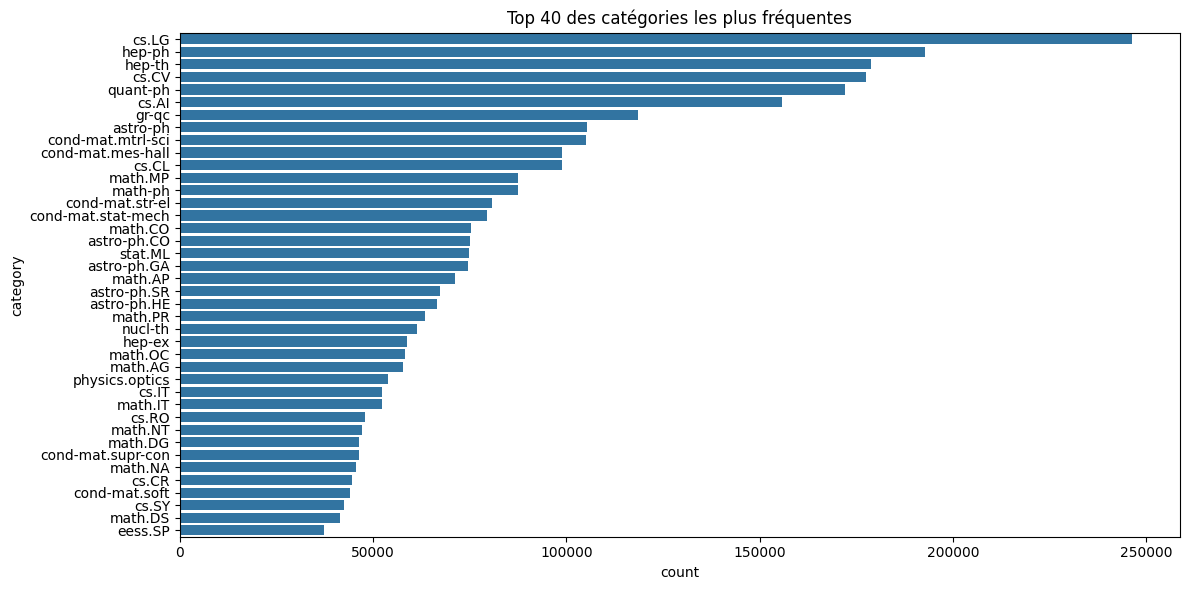

[Stage 63:================================================>       (33 + 5) / 38]

+------------------+------------------+---+---+
|           moyenne|        ecart_type|min|max|
+------------------+------------------+---+---+
|1.7232029478419202|0.9379573443249551|  1| 13|
+------------------+------------------+---+---+



In [66]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
def distribution_categories(df):
    
    # Analyser la distribution des labels
   
    # Analyse des catégories
    categories_df = df.select("categories")
    categories_df = categories_df.withColumn(
        "category_list", 
        F.split(F.col("categories"), " ")
    )
    
    # Compter les catégories
    categories_exploded = categories_df.select(
        F.explode("category_list").alias("category")
    )
    category_counts = categories_exploded.groupBy("category") \
        .count() \
        .orderBy(F.col("count").desc())
    #--------------------
    print("\n Distribution des catégories:")
    for row in category_counts:
        print(f"  {row['category']}: {row['count']}")
    #-------------------------------
    # Visualisation
    category_counts_pd = category_counts.limit(40).toPandas()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='count', y='category', data=category_counts_pd)
    plt.title('Top 40 des catégories les plus fréquentes')
    plt.tight_layout()
    plt.savefig('../data/results/top_categories.png')
    plt.show()
    
    # Distribution des catégories par article
    categories_per_article = categories_df.withColumn(
        "num_categories", 
        F.size("category_list")
    )
    
    categories_per_article.select(
        F.mean("num_categories").alias("moyenne"),
        F.stddev("num_categories").alias("ecart_type"),
        F.min("num_categories").alias("min"),
        F.max("num_categories").alias("max")
    ).show()
distribution_categories(df)

# # Aperçu des données
# df.printSchema()
# df.show(5, truncate=False)



In [67]:
def analyze_titles(df):
    """Analyse approfondie des titres"""
    print("\n" + "="*30)
    print(" ANALYSE DES TITRES")
       
    # 1. Longueur des titres
    df_with_lengths = df.withColumn("title_length_chars", F.length(F.col("title"))) \
                       .withColumn("title_length_words", F.size(F.split(F.col("title"), " ")))
    
    print("\n Statistiques de longueur des titres:")
    df_with_lengths.select(
        F.mean("title_length_chars").alias("Longueur moyenne (caractères)"),
        F.mean("title_length_words").alias("Mots moyens par titre"),
        F.stddev("title_length_chars").alias("Écart-type caractères"),
        F.stddev("title_length_words").alias("Écart-type mots")
    ).show(truncate=False)
    
    # 2. Distribution des longueurs
    length_stats_pd = df_with_lengths.select(
        "title_length_chars", "title_length_words"
    ).sample(False, 0.01).toPandas()  # Échantillon pour visualisation
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Histogramme des caractères
    axes[0].hist(length_stats_pd['title_length_chars'], bins=50, alpha=0.7, color='skyblue')
    axes[0].axvline(length_stats_pd['title_length_chars'].mean(), color='red', 
                   linestyle='dashed', linewidth=2, label=f'Moyenne: {length_stats_pd["title_length_chars"].mean():.0f}')
    axes[0].set_xlabel('Nombre de caractères')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution de la longueur des titres (caractères)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogramme des mots
    axes[1].hist(length_stats_pd['title_length_words'], bins=30, alpha=0.7, color='lightgreen')
    axes[1].axvline(length_stats_pd['title_length_words'].mean(), color='red', 
                   linestyle='dashed', linewidth=2, label=f'Moyenne: {length_stats_pd["title_length_words"].mean():.1f}')
    axes[1].set_xlabel('Nombre de mots')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title('Distribution de la longueur des titres (mots)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../data/results/title_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    return df_with_lengths

def analyze_abstracts(df):
    """Analyse approfondie des abstracts"""
    print("\n" + "="*30)
    print(" ANALYSE DES ABSTRACTS")
 
    
    # 1. Longueur des abstracts
    df_with_abstract_lengths = df.withColumn("abstract_length_chars", F.length(F.col("abstract"))) \
                                 .withColumn("abstract_length_words", F.size(F.split(F.col("abstract"), " ")))
    
    print("\n Statistiques de longueur des abstracts:")
    abstract_stats = df_with_abstract_lengths.select(
        F.mean("abstract_length_chars").alias("Longueur moyenne (caractères)"),
        F.mean("abstract_length_words").alias("Mots moyens par abstract"),
        F.min("abstract_length_chars").alias("Longueur minimale"),
        F.max("abstract_length_chars").alias("Longueur maximale"),
        F.stddev("abstract_length_chars").alias("Écart-type")
    ).collect()[0]
    
    print(f" Longueur moyenne : {abstract_stats['Longueur moyenne (caractères)']:.0f} caractères")
    print(f" Mots moyens : {abstract_stats['Mots moyens par abstract']:.0f} mots")
    print(f" Min/Max : {abstract_stats['Longueur minimale']} / {abstract_stats['Longueur maximale']} caractères")
    
    # 2. Distribution des longueurs (échantillon pour visualisation)
    abstract_sample = df_with_abstract_lengths.select(
        "abstract_length_chars", "abstract_length_words"
    ).sample(False, 0.005).toPandas()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme des caractères
    axes[0].hist(abstract_sample['abstract_length_chars'], bins=50, alpha=0.7, color='salmon')
    axes[0].axvline(abstract_sample['abstract_length_chars'].mean(), color='red', 
                   linestyle='dashed', linewidth=2, 
                   label=f'Moyenne: {abstract_sample["abstract_length_chars"].mean():.0f}')
    axes[0].set_xlabel('Nombre de caractères')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution de la longueur des abstracts (caractères)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Box plot des mots
    axes[1].boxplot(abstract_sample['abstract_length_words'], vert=False)
    axes[1].set_xlabel('Nombre de mots')
    axes[1].set_title('Distribution de la longueur des abstracts (mots)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../data/results/abstract_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_with_abstract_lengths


 ANALYSE DES TITRES

 Statistiques de longueur des titres:


+-----------------------------+---------------------+---------------------+-----------------+
|Longueur moyenne (caractères)|Mots moyens par titre|Écart-type caractères|Écart-type mots  |
+-----------------------------+---------------------+---------------------+-----------------+
|75.43979113742319            |10.282161499468558   |27.512870896370835   |4.058475822628965|
+-----------------------------+---------------------+---------------------+-----------------+



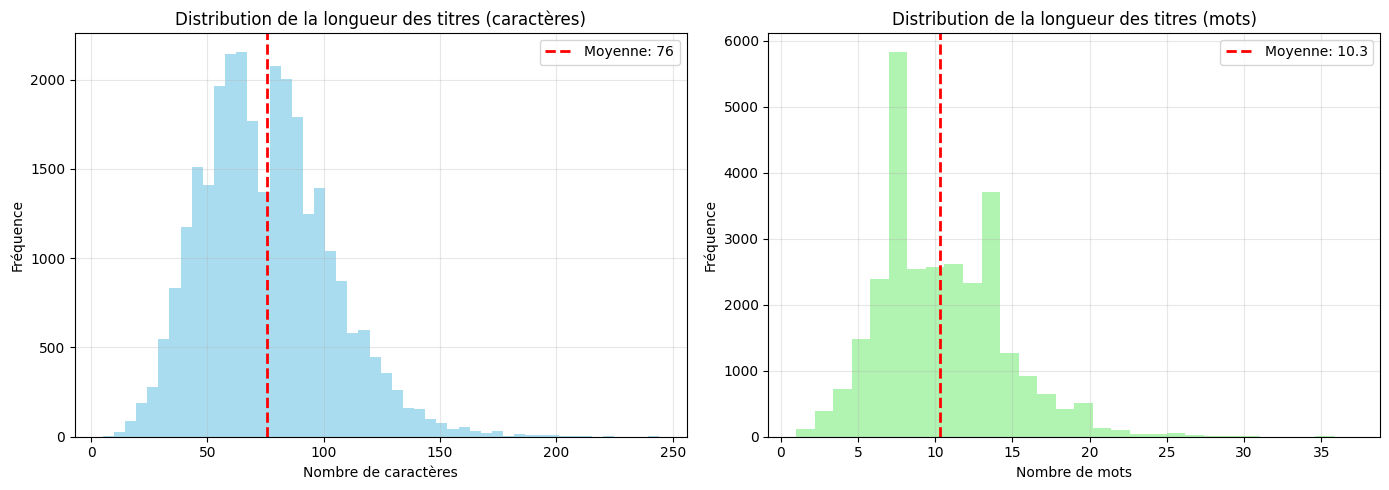

In [68]:
df_with_lengths=analyze_titles(df_selected)


 ANALYSE DES ABSTRACTS

 Statistiques de longueur des abstracts:


 Longueur moyenne : 988 caractères
 Mots moyens : 135 mots
 Min/Max : 3 / 6091 caractères


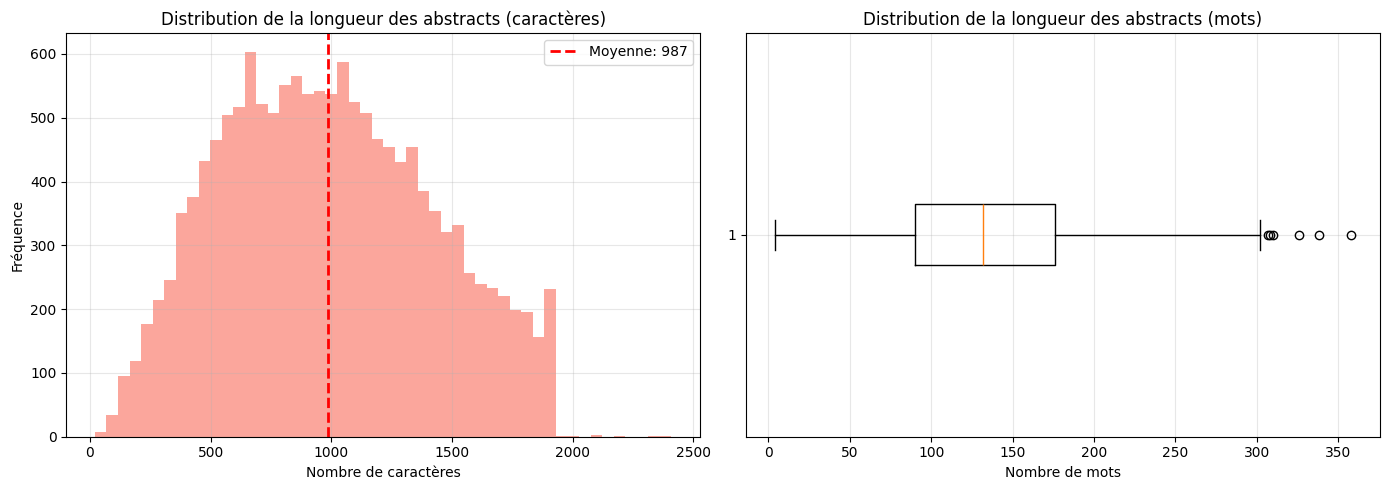

In [69]:
df_with_abstract_lengths=analyze_abstracts(df_selected)

In [70]:
### Enregistrement dataset avec colonnes importantes 
save_as_single_json(df_selected,"../data/processed/reduced_columns-arxiv_data.json")

Sauvegarde en cours vers ../data/processed/reduced_columns-arxiv_data.json...


Fichier sauvegardé : ../data/processed/reduced_columns-arxiv_data.json
 Taille : 3213.98 MB


'../data/processed/reduced_columns-arxiv_data.json'

In [71]:

# Nettoyage de la session Spark
spark.stop()